# Italian Financial Challenge 

**Student Name:** Moriondo Tommaso, Direnzo Carla, Pazienza Lorenzo, Raimondo Eleonora

**Challenge:** Revenue Forecasting

**Date:** 12/01/2025

---

## Instructions

This template provides a suggested structure for your challenge solution. You can adapt it to your needs, but make sure to cover all required sections:

1. Problem Statement and Objectives
2. Data Loading and Exploration
3. Data Preprocessing
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Interpretation and Business Insights
8. Conclusions and Future Work

**Remember:**
- Document your thought process with markdown cells
- Comment your code clearly
- Create visualizations to support your insights
- Interpret results in business terms
- Check the evaluation rubric to ensure you meet all criteria

## 1. Problem Statement and Objectives

**Challenge:** We focus on Challenge 3: **Revenue Forecasting**. Forecasting next-year revenue dynamics is high-impact for CFO/FP&A (early warning, budgeting, allocation).

### Target definition

`revenue_change` is indexed by `fiscal_year = t` and represents the **YoY % change from (t−1 → t)**.
Therefore it is **fully missing in 2018**, and supervised learning starts from **2019**.

### Objective (no-leakage)

We model the task as **past-only forecasting**:

* **Dataset-aligned learning task:** predict `revenue_change_t` using **only features from (t−1)** → **`X(t−1) → y(t)`**
* **Business interpretation:** given financials at year `t`, we forecast `revenue_change_{t+1}`.

### Success criteria

**Time-based holdout** to prevent temporal leakage:

* History (lags only): **2018**
* Train (target years): **2019–2020**
* Validation (target year): **2021**
* Scoring / submission years: **2022–2023**

**Primary metric:** RMSE on original scale.
**Secondary:** MAPE, MAE, Directional Accuracy.
We aim to beat a simple **ATECO sector-mean baseline** computed on train years only.

### Approach

* **Forecasting frame:** build `prev_*` snapshots by shifting year (t−1 → t), then merge to get `prev_*` + `revenue_change_t`.
* **Preprocessing:** `inf→NaN`; categoricals→`"UNK"`; numerics→median (+ optional missing flags). **Fit on train only**.
* **Models:** Ridge/ElasticNet vs LightGBM; optional target transforms (raw vs signed-log vs asinh). Select on 2021 RMSE.
* **Production simulation:** retrain up to 2021, save `pipeline_v1.joblib`, score **2022** (using 2021 features) and **2023** (using 2022 features).


In [181]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
from pathlib import Path
from ifc.config import load_data_config, load_split_config, resolve_project_root
from ifc.data_quality import run_all_checks

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Exploration (task 0)

Load the training data and perform initial exploration.

In [118]:
data_cfg = load_data_config()
split_cfg = load_split_config()

train_path, test_path = data_cfg.resolve_paths()
print(data_cfg, "\n")
print(split_cfg, "\n")

print(f"training path: {train_path}, exists? {train_path.exists()}")
print(f"test path: {test_path}, exists? {test_path.exists()}")

id_col, time_col, target = data_cfg.id_col, data_cfg.time_col, data_cfg.target_col
print(f"Company_id column: {id_col}\nFiscal_year column: {time_col}\nTarget column: {target}\n")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

DataConfig(train_path=WindowsPath('data/processed/train_data.csv'), test_path=WindowsPath('data/processed/test_features.csv'), id_col='company_id', time_col='fiscal_year', target_col='revenue_change', drop_cols=['bankruptcy_next_year', 'financial_health_class']) 

SplitConfig(strategy='forecasting_holdout', time_col='fiscal_year', id_col='company_id', target_col='revenue_change', shuffle=False, horizon_years=1, train_target_years=[2019, 2020], val_target_years=[2021], test_target_years=[2022, 2023]) 

training path: C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\train_data.csv, exists? True
test path: C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\test_features.csv, exists? True
Company_id column: company_id
Fiscal_year column: fiscal_year
Target column: revenue_change

train_df: (11828, 30)
test_df : (5811, 27)


In [119]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  object 
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  object 
 3   region                  11828 non-null  object 
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  object 
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null

float64    21
object      5
int64       4
Name: count, dtype: int64


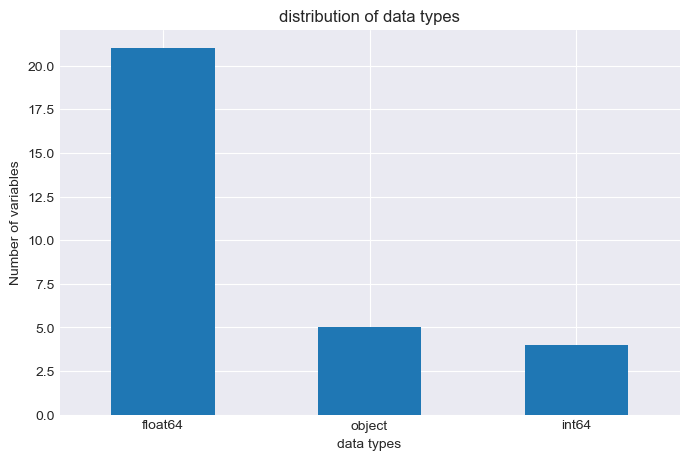

In [120]:

dtype_counts = train_df.dtypes.value_counts()

print(dtype_counts)

plt.figure(figsize=(8, 5))
dtype_counts.plot(kind='bar')

plt.title('distribution of data types')
plt.xlabel('data types')
plt.ylabel('Number of variables')
plt.xticks(rotation=0)  
plt.show()

In [121]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fiscal_year,11828.0,2.019495e+03,1.116482e+00,2.018000e+03,2.018000e+03,2.019000e+03,2.020000e+03,2.021000e+03
ateco_sector,11828.0,4.582770e+01,1.667718e+01,1.000000e+01,4.100000e+01,4.600000e+01,5.600000e+01,8.200000e+01
years_in_business,11828.0,3.517940e+01,1.990809e+01,0.000000e+00,1.800000e+01,3.500000e+01,5.200000e+01,7.100000e+01
total_fixed_assets,11828.0,1.029206e+09,6.120958e+09,1.267167e+06,7.319803e+07,1.905995e+08,5.398741e+08,2.548712e+11
current_assets,11828.0,1.438435e+09,6.873106e+09,1.278800e+06,1.244471e+08,3.125597e+08,8.387197e+08,2.512549e+11
total_assets,11828.0,2.467641e+09,1.248305e+10,2.545968e+06,2.087793e+08,5.212379e+08,1.394478e+09,5.061262e+11
shareholders_equity,11828.0,9.163141e+08,5.023564e+09,-3.330561e+09,7.070428e+07,1.815958e+08,5.022747e+08,1.956145e+11
total_debt,11828.0,1.551327e+09,7.724478e+09,1.839791e+06,1.294646e+08,3.264152e+08,8.795087e+08,3.105116e+11
short_term_debt,11828.0,8.534656e+08,4.360360e+09,8.985461e+05,6.925617e+07,1.744802e+08,4.777298e+08,1.699685e+11
long_term_debt,11828.0,6.978617e+08,3.493369e+09,9.412449e+05,5.666362e+07,1.462585e+08,3.960070e+08,1.405431e+11


In [ ]:

report = run_all_checks(train_df, test_df, verbose=True)
report["summary"]


### Fiscal years check:
The range of fiscal_year in train_dataset is correct: from 2018 to 2021

In [122]:
unique_id = train_df[id_col].nunique()
unique_id_percentage = unique_id/len(train_df[id_col])*100

print(f'unique IDs:{unique_id}')
print(f'unique id percentage:{unique_id_percentage}')

unique IDs:2999
unique id percentage:25.355089617855935


### unique IDs 
are ~ 25% of the dataset, this is means that every companies appear ~ 4 times (1 for each fiscal year)

In [123]:
def missing_summary(df):
    missing_values = df.isnull().sum()
    missing_pct = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_values,
        'Percentage': missing_pct,
        'd_type': df.dtypes
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    return missing_df




In [124]:
missing_train = missing_summary(train_df)
print("Missing Values train:")
print(missing_train)

Missing Values train:
                Missing Count  Percentage   d_type
revenue_change           2999   25.355090  float64
province                  919    7.769699   object
roe                        45    0.380453  float64
leverage                   45    0.380453  float64


## Missingness evaluation (task 1 EDA)
The target `revenue_change`'s missingness is allign with the provided documentation, we'll conduct further analysis to state the nature of this missingness.

The other missing values will be handle with a imputation strategy

In [125]:

agg_funcs = {
    'Total Rows': 'size',
    'Missing Count': lambda x: x.isnull().sum(),
    'Missing %': lambda x: (x.isnull().sum() / len(x)) * 100
}

missing_per_year = train_df.groupby(time_col)[target].agg(**agg_funcs)

print(missing_per_year)

             Total Rows  Missing Count   Missing %
fiscal_year                                       
2018               2961           2961  100.000000
2019               2979             38    1.275596
2020               2956              0    0.000000
2021               2932              0    0.000000


The missingness in `revenue_change` is mostly in 2018 this because the target is defined on the prevoius year observation, so since there's not 2017 data, the 2018 is all NaN. The year 2018 will be used to predict the `revenue_change` in 2019

In [126]:
panel = (train_df[[id_col,time_col]].drop_duplicates().sort_values([id_col,time_col]))

years_per_company = panel.groupby(id_col)[time_col].agg(
    n_years = 'nunique',
    min_year= 'min',
    max_year= 'max'
)

dist_n = years_per_company["n_years"].value_counts().sort_index()
dist_n_pct = (dist_n / dist_n.sum() * 100).round(2)

print("Distribution n_years per company:")
print(pd.DataFrame({"count": dist_n, "pct": dist_n_pct}))

# 2) Gap check 
def has_gap(years: pd.Series) -> bool:
    yrs = np.sort(years.unique())
    return (np.diff(yrs) > 1).any()

gap_flag = panel.groupby(id_col)[time_col].apply(has_gap)
print(f"\nCompanies with temporal gaps: {int(gap_flag.sum())} ({gap_flag.mean()*100:.2f}%)")

has_2018 = panel.groupby(id_col)[time_col].apply(lambda s: 2018 in set(s))
print(f"\ncompanies with 2018 records: {int(has_2018.sum())} | without 2018 recors: {int((~has_2018).sum())}")

start_dist = years_per_company["min_year"].value_counts().sort_index()
end_dist = years_per_company["max_year"].value_counts().sort_index()
print("\nDistribution min_year (start):")
print(start_dist)
print("\nDistribution max_year (end):")
print(end_dist)

mask_2019_missing = (train_df[time_col] == 2019) & (train_df[target].isna())
missing_2019_companies = set(train_df.loc[mask_2019_missing, id_col])
if len(missing_2019_companies) > 0:
    share_without_2018 = (~has_2018.loc[list(missing_2019_companies)]).mean() * 100
    print(f"\n2019 target-missing rows: {mask_2019_missing.sum()}")
    print(f"Companies involved: {len(missing_2019_companies)}")
    print(f"% companies without 2018: {share_without_2018:.2f}%")


Distribution n_years per company:
         count    pct
n_years              
1           20   0.67
2           24   0.80
3           60   2.00
4         2895  96.53

Companies with temporal gaps: 0 (0.00%)

companies with 2018 records: 2961 | without 2018 recors: 38

Distribution min_year (start):
min_year
2018    2961
2019      38
Name: count, dtype: int64

Distribution max_year (end):
max_year
2018      20
2019      23
2020      24
2021    2932
Name: count, dtype: int64

2019 target-missing rows: 38
Companies involved: 38
% companies without 2018: 100.00%


## Panel Completeness (Train 2018–2021) — Key Findings

- **Near-balanced firm-year panel:** 2,999 unique companies across 11,828 rows (~3.94 rows/company).
- **Years per company distribution:**
  - 4 years: **2,895 companies (96.53%)**
  - 3 years: **60 (2.00%)**
  - 2 years: **24 (0.80%)**
  - 1 year: **20 (0.67%)**
- **No temporal gaps:** **0 companies (0.00%)** show missing intermediate years (when present, fiscal years are consecutive).
- **2018 coverage:**
  - Companies **with** 2018 records: **2,961**
  - Companies **without** 2018 records: **38**
  - `min_year` distribution: **2018 → 2,961**, **2019 → 38**
- **End-year distribution (`max_year`):**
  - 2018 → 20, 2019 → 23, 2020 → 24, 2021 → 2,932
- **Target missingness in 2019 is fully explained by missing history:**
  - 2019 `revenue_change` missing rows: **38**
  - Companies involved: **38**
  - **100%** of these companies **lack 2018 history**, meaning `revenue_change_2019` is not computable (no t−1 value).

**Implication:** Lag features based on `shift(1)` are highly reliable given the consecutive-year structure; first-observation cases (no prior year) are rare and can be handled via missing flags / `is_first_observation`.


# EDA starts year 

Task 2: target distribution

In [127]:

def p25(x): return x.quantile(0.25)
def p75(x): return x.quantile(0.75)
def p90(x): return x.quantile(0.90)
def p95(x): return x.quantile(0.95)
def p99(x): return x.quantile(0.99)


tmp = train_df[[time_col, target]].copy()

metrics = tmp.groupby(time_col)[target].agg([
    'count', 
    'mean', 
    'median', 
    p25, 
    p75, 
    p90, 
    p95, 
    p99
])



print(metrics.round(2))

             count   mean  median    p25     p75     p90      p95      p99
fiscal_year                                                               
2018             0    NaN     NaN    NaN     NaN     NaN      NaN      NaN
2019          2941  396.5    1.82 -68.38  242.26  872.97  1753.54  6787.59
2020          2956  475.0    0.34 -69.50  231.29  895.66  1722.46  7079.24
2021          2932  488.8    7.50 -67.35  240.05  884.68  1767.23  5181.84


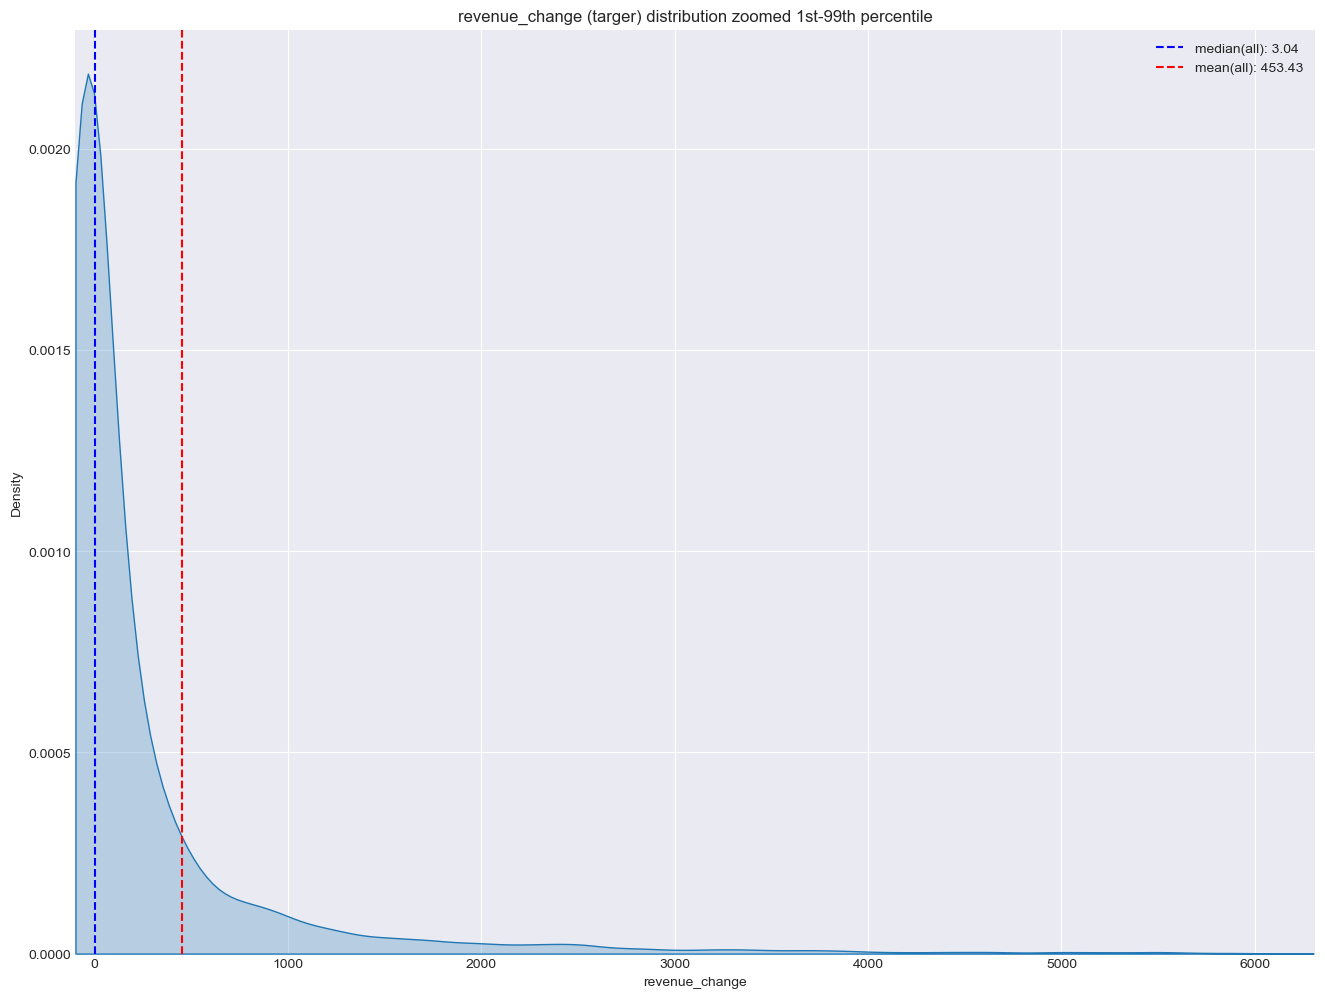

In [128]:
y = train_df[target].dropna().copy()
r_low, r_high = y.quantile([0.01, 0.99])
y_core = y[(y >= r_low) & (y <= r_high)]

plt.figure(figsize=(16,12))
sns.kdeplot(x=y_core, fill=True, cut=0)
plt.axvline(y.median(), color="blue", linestyle="--", label=f"median(all): {y.median():.2f}")
plt.axvline(y.mean(),   color="red",  linestyle="--", label=f"mean(all): {y.mean():.2f}")
plt.xlim(r_low, r_high)
plt.title('revenue_change (targer) distribution zoomed 1st-99th percentile')
plt.legend()
plt.show()

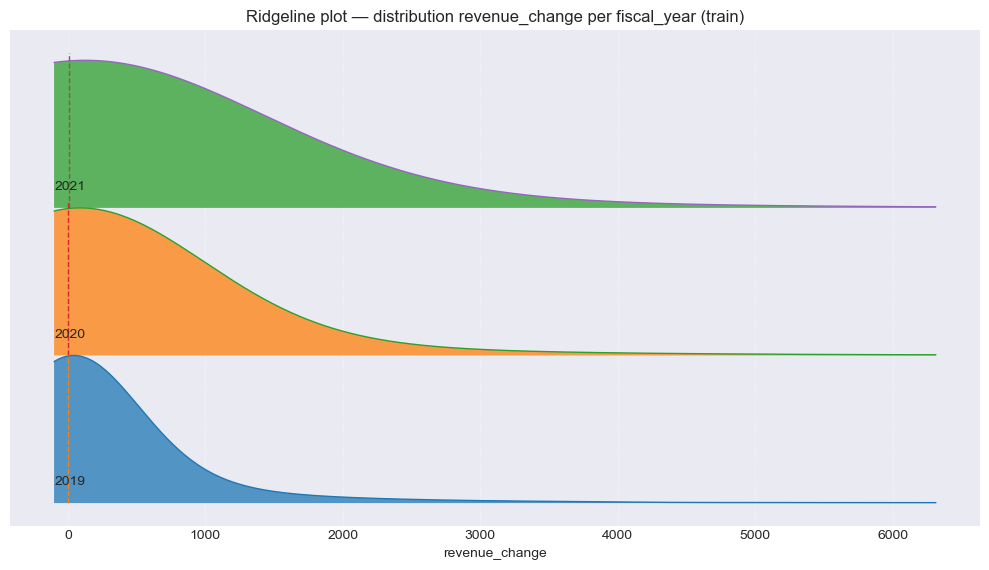

In [129]:
df = train_df[np.isfinite(train_df["revenue_change"])].copy()

years = sorted(df["fiscal_year"].unique())

x_low, x_high = np.percentile(df["revenue_change"], [0, 99])
x = np.linspace(x_low, x_high, 600)

fig, ax = plt.subplots(figsize=(10, 1.6 * len(years) + 1))
gap = 1.0

for i, y in enumerate(years):
    vals = df.loc[df["fiscal_year"] == y, "revenue_change"].to_numpy()
    vals = vals[np.isfinite(vals)]   # sicurezza extra

    
    if len(vals) < 10 or np.std(vals) == 0:
        
        med = np.median(vals) if len(vals) else np.nan
        offset = i * gap
        if np.isfinite(med):
            ax.plot([med, med], [offset, offset + 0.8], linestyle="--", linewidth=1.2)
            ax.text(x_low, offset + 0.1, str(y), va="bottom", ha="left")
        continue

    kde = gaussian_kde(vals)
    dens = kde(x)
    dens = dens / dens.max()

    offset = i * gap
    ax.fill_between(x, offset, offset + dens, alpha=0.75)
    ax.plot(x, offset + dens, linewidth=1.0)

    med = np.median(vals)
    ax.plot([med, med], [offset, offset + 1.05], linestyle="--", linewidth=1.0)

    ax.text(x_low, offset + 0.1, str(y), va="bottom", ha="left")

ax.set_title("Ridgeline plot — distribution revenue_change per fiscal_year (train)")
ax.set_xlabel("revenue_change")
ax.set_yticks([])
ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

Task 3 (target transform)


3.	TARGET DISTRIBUTION — HEAVY-TAIL VIEW (TRANSFORM-FRIENDLY)

The target variable `revenue_change` is defined as a "year over year" percentage change. Its distribution is often heavy-tailed: extreme values can arise not only from large absolute changes in revenue, but also from very small prior-year values in the denominator. To obtain a readable view of the full distribution while preserving sign information, we apply the signed-log transform:

$$
y_{\mathrm{slog}} = \mathrm{sign}(y)\,\log\left(1 + \left|y\right|\right)
$$

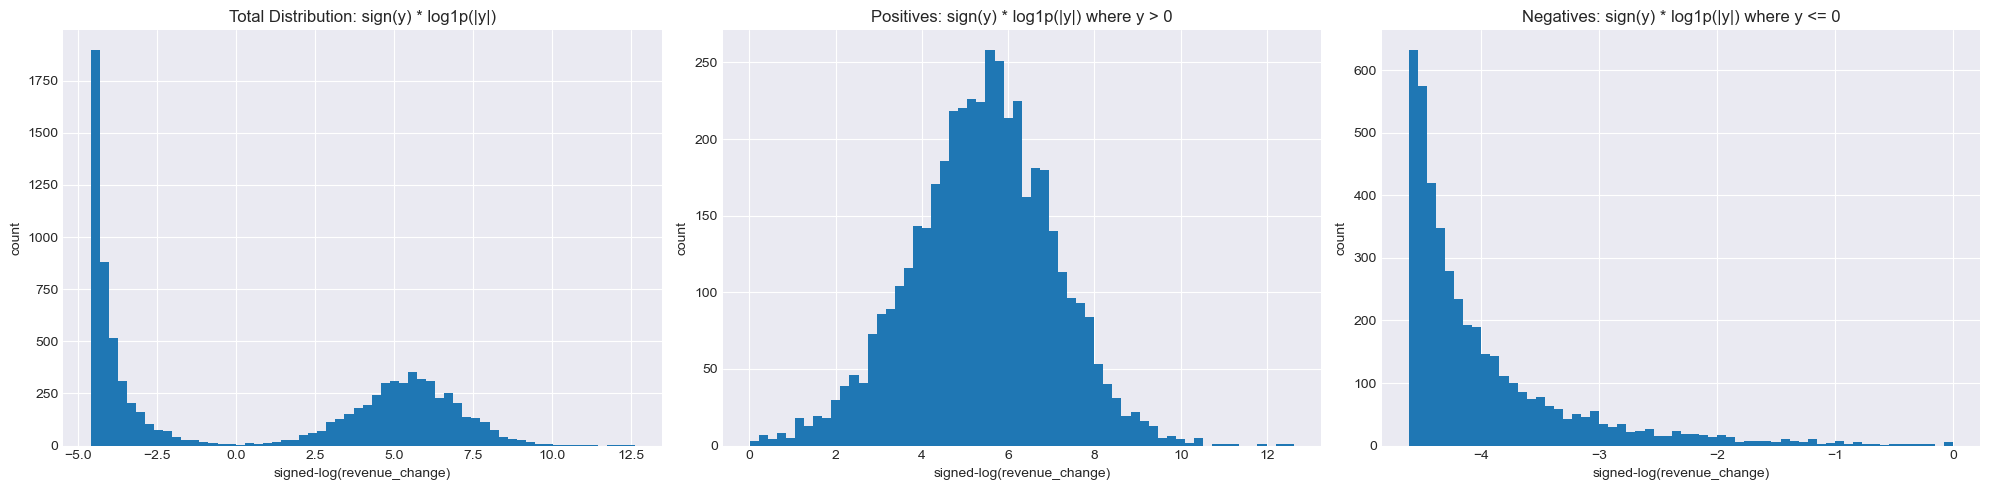

In [130]:


y = df[target].dropna().copy()

# apply the tranformations
y_slog = np.sign(y) * np.log1p(np.abs(y))
y_slog_pos = y_slog[y_slog > 0]
y_slog_neg = y_slog[y_slog <= 0]

# 2. Create the 1x3 Grid
fig, axes = plt.subplots(1, 3, figsize=(20, 5)) 

# 1st plot full distribution
axes[0].hist(y_slog, bins=60)
axes[0].set_title("Total Distribution: sign(y) * log1p(|y|)")
axes[0].set_xlabel("signed-log(revenue_change)")
axes[0].set_ylabel("count")

# 2nd Positives Only (y > 0) ---
axes[1].hist(y_slog_pos, bins=60)
axes[1].set_title("Positives: sign(y) * log1p(|y|) where y > 0")
axes[1].set_xlabel("signed-log(revenue_change)")
axes[1].set_ylabel("count")

# 3rd Negatives & Zero (y <= 0)
axes[2].hist(y_slog_neg, bins=60)
axes[2].set_title("Negatives: sign(y) * log1p(|y|) where y <= 0")
axes[2].set_xlabel("signed-log(revenue_change)")
axes[2].set_ylabel("count")

# Adjust spacing between plots to prevent overlap
plt.tight_layout()
plt.show()

The overall signed-log distribution looks bimodal due to the mixture of negative and positive outcomes; within each sign the distribution is largely unimodal.

In [131]:
tmp = train_df[(train_df[target].notna()) & (train_df[time_col] > 2018)].copy()

summary = tmp.groupby(time_col).agg(
    n_total=(target, "size"),
    n_neg=(target, lambda s: (s < 0).sum()),
)
summary["pct_neg"] = (summary["n_neg"] / summary["n_total"] * 100).round(2)

summary


,n_total,n_neg,pct_neg
fiscal_year,,,
2019,2941,1459,49.61
2020,2956,1474,49.86
2021,2932,1427,48.67


## Signed-log target transform — Assumptions & Modeling Risks 

### Transform definition
We transform the target `revenue_change` using:

$$
y_{\mathrm{slog}} = \mathrm{sign}(y)\,\log\left(1 + \left|y\right|\right)
$$

and invert predictions with:

$$
\hat{y} = \mathrm{sign}\left(\hat{y}_{\mathrm{slog}}\right)\left(\exp\left(\left|\hat{y}_{\mathrm{slog}}\right|\right)-1\right)
$$

---

## Assumptions (explicit)

### A1) Target is real-valued with meaningful sign
- Positive values mean growth, negative values mean contraction.
- Preserving sign is important for business interpretation (growth vs decline).

### A2) Extreme magnitudes are partly “scale artifacts”
- Very large `revenue_change` values may arise from:
  - genuine large changes, and/or
  - small prior-year denominators (near-zero `production_value_{t-1}`).
- Compressing magnitudes is desirable to prevent a few extreme points from dominating learning.

### A3) We care about stability more than perfect fidelity on extremes
- The transform prioritizes learning signal in the bulk of the distribution.
- Errors on extremely rare events are expected to be less learnable with available features.

### A4) Model can be trained on transformed space without leakage
- The transform is deterministic and does not use future information.
- All preprocessing (imputation/encoding/scaling) is fit on train-fold only and applied to val/test.

### A5) Evaluation must remain on the original business scale
- The challenge metric (and stakeholders) care about `revenue_change` in original units.
- Therefore: train on $y_{\mathrm{slog}}$, evaluate on inverted predictions in original $y$.

---

## Key model risks / criticalities

### R1) Boundary mass on the negative side (near -100%)
- If `revenue_change` is bounded near -100%, many negative observations can concentrate near this boundary.
- In signed-log space, values near -100% map around $-\log(1+100)$, creating a dense region.
**Implication:** the model may struggle to distinguish between “very negative” values (e.g., -80% vs -99%) because they are compressed into a narrow range.

**Mitigation:**
- Report errors separately for $y < 0$ vs $y \ge 0$.
- Consider a simple flag later (Task 5): `is_low_prev_production_value`.

---

### R2) Apparent bimodality is a mixture of signs (two populations)
- The overall transformed distribution can look bimodal because it mixes:
  - a negative contraction population and
  - a positive growth population.
**Implication:** a single regressor may learn a “central compromise” and underperform on one side if the mechanisms differ.

**Mitigation:**
- Segment-level evaluation: metrics on $y<0$ and $y>0$.
- Error analysis for extremes (top 1% $|y|$) vs core (p1–p99).

---

### R3) Heteroskedasticity and asymmetric business costs
- Even after transform, error variance may differ across regimes (negative vs positive, firm size, sectors).
**Implication:** RMSE alone can be misleading.

**Mitigation:**
- Primary: RMSE on original scale (as required).
- Secondary: MAE + Directional Accuracy (sign correctness).
- Optional reporting: “core RMSE” on p1–p99 subset.

---

### R4) Bias introduced by inverse transform (Jensen’s inequality)
- Training in log space and then inverting can bias predictions on the original scale,
  especially for high-variance regions (extremes).
**Implication:** the model may underpredict extreme positive spikes after inversion.

**Mitigation:**
- Accept as trade-off for stability.
- Document as limitation; quantify performance on extreme subset.

---

### R5) Metrics can be dominated by rare extremes on original scale
- Even with transformed training, evaluation on original scale (RMSE) can still be driven by rare outliers.
**Implication:** model ranking can be sensitive to a handful of points.

**Mitigation:**
- Always accompany RMSE with MAE and a “core RMSE” narrative for interpretability.
- Keep a dedicated “extreme cases” error analysis section.

---

### R6) Transform does not fix root-cause outliers (denominator effects)
- If extremes are driven by near-zero `production_value_{t-1}` or structural events (M&A/perimeter changes),
  the transform only reduces their influence; it does not make them predictable.
**Implication:** there is an irreducible error floor for such events.

**Mitigation:**
- Task 5: validate denominator mechanism with `production_value_lag1`.
- Add simple missing/low-denominator flags rather than complex mixture models.


4.	TEMPORAL DRIFT IN TARGET (2019–2020–2021) (COVID V-SHAPE)

We evaluate whether `revenue_change` exhibits a year-dependent shift in distribution, focusing on fiscal years 2019, 2020 and 2021.
We provide:
1. A year-level summary table with count, mean, median and tail percentiles (p95, p99).
2. A boxplot by year

ATTENTION: for the boxplot only, we clip values to the 1%–99% range to improve readability. This is a visualization convenience and must not be interpreted as removing outliers from the dataset.

In [132]:
years = [2019, 2020, 2021]
df_3y = df.loc[df[time_col].isin(years), [time_col, target]].dropna().copy()

summary = (
    df_3y.groupby(time_col)[target]
    .agg(
        n="count",
        mean="mean",
        p1 = lambda s: s.quantile(0.01),
        p5 = lambda s: s.quantile(0.05),
        median="median",
        IQR =  lambda s: s.quantile(0.75) - s.quantile(0.25),
        p95=lambda s: s.quantile(0.95),
        p99=lambda s: s.quantile(0.99),
    )
    .reset_index()
    .sort_values(time_col)
)



In [133]:

summary_fmt = summary.copy()

# round numeric columns
num_cols = ["mean", "median", "p1", "p5", "IQR", "p95", "p99"]
summary_fmt[num_cols] = summary_fmt[num_cols].round(2)

# ensure n is int
summary_fmt["n"] = summary_fmt["n"].astype(int)

# pretty display (Jupyter)
summary_fmt.style.format({
    "n": "{:,}",
    "mean": "{:,.2f}",
    "median": "{:,.2f}",
    "p1" : "{:,.2f}",
    "p5" : "{:,.2f}",
    "IQR": "{:,.2f}",
    "p95": "{:,.2f}",
    "p99": "{:,.2f}",
}).set_caption("Revenue_change drift summary by fiscal_year (2019–2021)")


,fiscal_year,n,mean,p1,p5,median,IQR,p95,p99
0,2019,"2,941",396.50,-98.63,-94.35,1.82,310.64,"1,753.54","6,787.59"
1,2020,"2,956",475.00,-98.31,-93.85,0.34,300.79,"1,722.46","7,079.24"
2,2021,"2,932",488.80,-98.82,-95.14,7.50,307.40,"1,767.23","5,181.84"


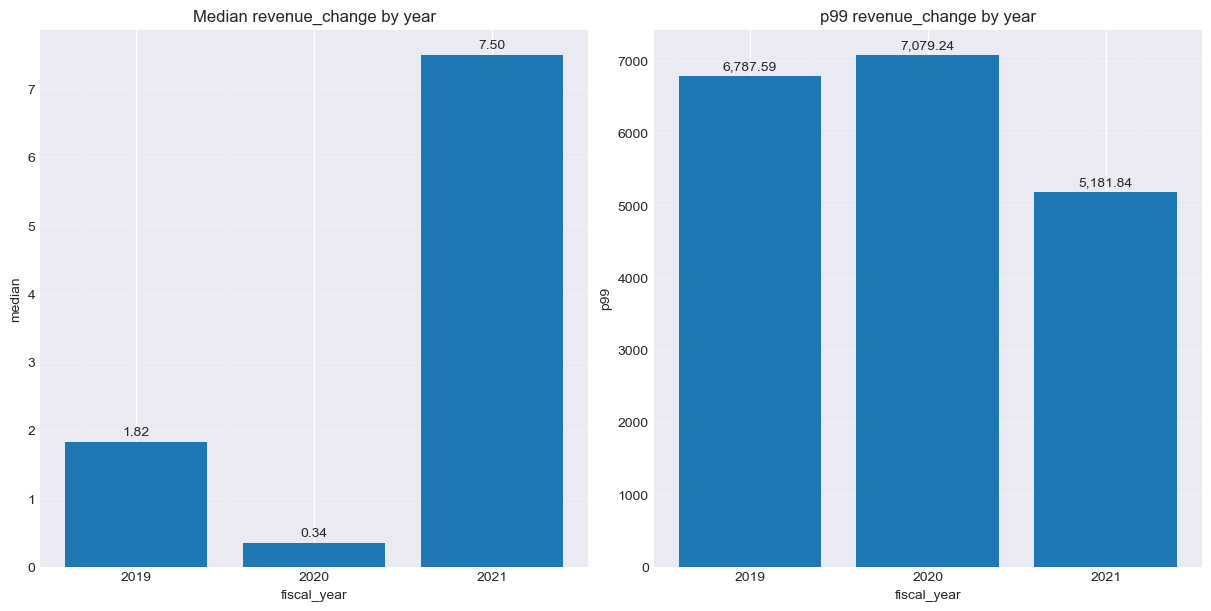

In [134]:

summary_sorted = summary.sort_values("fiscal_year").copy()
x = summary_sorted["fiscal_year"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Chart 1: Median 
bars0 = axes[0].bar(x, summary_sorted["median"])
axes[0].set_title("Median revenue_change by year")
axes[0].set_xlabel("fiscal_year")
axes[0].set_ylabel("median")
axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# value labels
for b in bars0:
    h = b.get_height()
    axes[0].annotate(f"{h:,.2f}",
                     (b.get_x() + b.get_width()/2, h),
                     ha="center", va="bottom",
                     xytext=(0, 3), textcoords="offset points")

# Chart 2: p99 
bars1 = axes[1].bar(x, summary_sorted["p99"])
axes[1].set_title("p99 revenue_change by year")
axes[1].set_xlabel("fiscal_year")
axes[1].set_ylabel("p99")
axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# value labels
for b in bars1:
    h = b.get_height()
    axes[1].annotate(f"{h:,.2f}",
                     (b.get_x() + b.get_width()/2, h),
                     ha="center", va="bottom",
                     xytext=(0, 3), textcoords="offset points")

plt.show()


## Temporal drift in `revenue_change` (2019–2021) — Findings

### Business interpretation
- **Typical firm outcome shifts:** the **median** dips in 2020 and rebounds in 2021, suggesting a mild contraction/recovery pattern in the “typical” company (median: **1.82 → 0.34 → 7.50**).
- **Extreme upside changes:** the **top 1%** outcomes are more pronounced in 2019–2020 and **drop in 2021**, indicating fewer/less extreme “exceptional growth” events in 2021 (p99: **6,787.59 → 7,079.24 → 5,181.84**).
- **Core spread and downside tail are stable:** **IQR** and **p95** remain broadly stable, and the **downside extremes** (p1, p5) are also stable, suggesting the worst contractions did not materially deepen across years.

### Modeling implications
- **Time-aware validation is justified:** the shift in central tendency (median) indicates mild **distribution shift**, so 2021 is not fully i.i.d. with 2019–2020.
- **RMSE sensitivity to extremes:** changes in **p99** imply that a few extreme observations can disproportionately affect RMSE and perceived performance across years.
- **Robust training remains appropriate:** given heavy tails and tail instability, we keep training on the **signed-log target** and evaluate on the original scale, complementing RMSE with secondary diagnostics (e.g., MAE / directional accuracy and core-range checks).


### Task Outlier mechanism diagnosis (ratio explosion check) Carla

**Output**
- Create `production_value_lag1` = groupby(`company_id`) + shift(1) on `production_value`
- Table: top 20 absolute `revenue_change` rows with:
  - `company_id`, `fiscal_year`, `production_value_lag1`, `production_value`, `revenue_change`
- (Optional) quantify: share of extreme targets where `production_value_lag1` is near 0 (e.g., below p5)

**Why**
- Explains extreme values (often denominator near 0), justifying winsorization / robust metrics.

In [135]:

pv_col = "production_value"

# 1) Sort + lag
df = train_df.sort_values([id_col, time_col]).copy()
df["pv_lag1"] = df.groupby(id_col)[pv_col].shift(1)

# 2) Keep supervised years (target available years) + keep rows with target
tmp = df[df[time_col].isin([2019, 2020, 2021])].copy()
tmp = tmp.dropna(subset=[target])  # target must exist for Task 5

# 3) Quick sanity checks (print)
print("tmp shape:", tmp.shape)
print("pv_lag1 missing in tmp:", tmp["pv_lag1"].isna().sum())
print(tmp[[id_col, time_col, pv_col, "pv_lag1", target]].head(5))


tmp shape: (8829, 31)
pv_lag1 missing in tmp: 0
   company_id  fiscal_year  production_value       pv_lag1  revenue_change
1  COMP_00000         2019      4.289159e+08  1.846636e+09          -76.77
2  COMP_00000         2020      6.956197e+09  4.289159e+08         1521.81
3  COMP_00000         2021      5.031839e+08  6.956197e+09          -92.77
5  COMP_00001         2019      1.595547e+09  4.113380e+08          287.89
6  COMP_00001         2020      1.827539e+08  1.595547e+09          -88.55


In [136]:
# Step 5.2: top 20 by absolute revenue_change
top20 = (
    tmp.assign(abs_target=tmp[target].abs())
       .sort_values("abs_target", ascending=False)
       .head(20)
       [[id_col, time_col, "pv_lag1", pv_col, target, "abs_target"]]
)

# opzionale: format numeri per leggere meglio
top20_view = top20.copy()
top20_view["pv_lag1"] = top20_view["pv_lag1"].map(lambda x: f"{x:,.0f}")
top20_view[pv_col]    = top20_view[pv_col].map(lambda x: f"{x:,.0f}")
top20_view[target]    = top20_view[target].map(lambda x: f"{x:,.2f}")
top20_view["abs_target"] = top20["abs_target"].map(lambda x: f"{x:,.2f}")

top20_view


,company_id,fiscal_year,pv_lag1,production_value,revenue_change,abs_target
9793,COMP_02485,2021,"33,511,675","101,281,157,693","302,126.48","302,126.48"
380,COMP_00096,2020,"4,856,124","10,349,872,230","213,030.29","213,030.29"
5876,COMP_01490,2021,"9,048,074","12,322,721,821","136,091.65","136,091.65"
8571,COMP_02174,2019,"23,637,468","17,520,236,230","74,020.61","74,020.61"
11557,COMP_02932,2019,"30,808,139","18,930,380,808","61,346.04","61,346.04"
3543,COMP_00896,2021,"136,304,675","72,083,171,943","52,783.86","52,783.86"
1765,COMP_00450,2020,"79,064,388","29,263,821,275","36,912.64","36,912.64"
11471,COMP_02910,2020,"787,092,744","276,235,838,640","34,995.72","34,995.72"
1840,COMP_00469,2019,"468,143,115","157,097,764,915","33,457.64","33,457.64"
2959,COMP_00749,2020,"38,978,618","12,754,583,116","32,622.00","32,622.00"


In [137]:


tmp2 = tmp.copy()


thr_p5  = tmp2["pv_lag1"].quantile(0.05)
thr_p10 = tmp2["pv_lag1"].quantile(0.10)

tmp2["denom_small_p5"]  = tmp2["pv_lag1"] <= thr_p5
tmp2["denom_small_p10"] = tmp2["pv_lag1"] <= thr_p10


thr_ext = tmp2[target].abs().quantile(0.99)
tmp2["is_extreme_abs_p99"] = tmp2[target].abs() >= thr_ext


diag = pd.DataFrame({
    "thr_p5_pv_lag1": [thr_p5],
    "thr_p10_pv_lag1": [thr_p10],
    "thr_extreme_abs_p99": [thr_ext],
    "extreme_count": [int(tmp2["is_extreme_abs_p99"].sum())],
    "pct_extremes_with_denom_small_p5": [round(tmp2.loc[tmp2["is_extreme_abs_p99"], "denom_small_p5"].mean()*100, 2)],
    "pct_extremes_with_denom_small_p10": [round(tmp2.loc[tmp2["is_extreme_abs_p99"], "denom_small_p10"].mean()*100, 2)],
})



In [138]:
diag_fmt = diag.copy()

diag_fmt.style.format({
    "thr_p5_pv_lag1": "{:,.0f}",         
    "thr_p10_pv_lag1": "{:,.0f}",        
    "thr_extreme_abs_p99": "{:,.2f}",     
    "extreme_count": "{:d}",
    "pct_extremes_with_denom_small_p5": "{:.2f}%",
    "pct_extremes_with_denom_small_p10": "{:.2f}%"
}).set_caption("Denominator effect diagnostic (extremes = top 1% |revenue_change|)")


,thr_p5_pv_lag1,thr_p10_pv_lag1,thr_extreme_abs_p99,extreme_count,pct_extremes_with_denom_small_p5,pct_extremes_with_denom_small_p10
0,"78,369,337","126,082,105","6,313.31",89,33.71%,48.31%


further analysis on scale_ratio= production_value / pv_lag1
	​


In [139]:

tmp3 = tmp2.copy()

# 1) scale ratio (avoid any potential numerical issues)
tmp3 = tmp3[(tmp3["pv_lag1"] > 0) & (tmp3["production_value"] > 0)].copy()
tmp3["scale_ratio"] = tmp3["production_value"] / tmp3["pv_lag1"]
tmp3["log_scale_ratio"] = np.log1p(tmp3["scale_ratio"])

# 2) summary by extreme flag
ratio_summary = (
    tmp3.groupby("is_extreme_abs_p99")[["scale_ratio", "log_scale_ratio"]]
        .agg(
            n=("scale_ratio", "count"),
            median_ratio=("scale_ratio", "median"),
            p90_ratio=("scale_ratio", lambda s: s.quantile(0.90)),
            p95_ratio=("scale_ratio", lambda s: s.quantile(0.95)),
            p99_ratio=("scale_ratio", lambda s: s.quantile(0.99)),
            median_log_ratio=("log_scale_ratio", "median"),
            p95_log_ratio=("log_scale_ratio", lambda s: s.quantile(0.95)),
        )
        .reset_index()
)

ratio_summary


,is_extreme_abs_p99,n,median_ratio,p90_ratio,p95_ratio,p99_ratio,median_log_ratio,p95_log_ratio
0,False,8740,1.005025,9.097166,16.087040,36.423784,0.695657,2.838320
1,True,89,100.790832,328.891269,580.211661,2238.218364,4.622920,6.362451


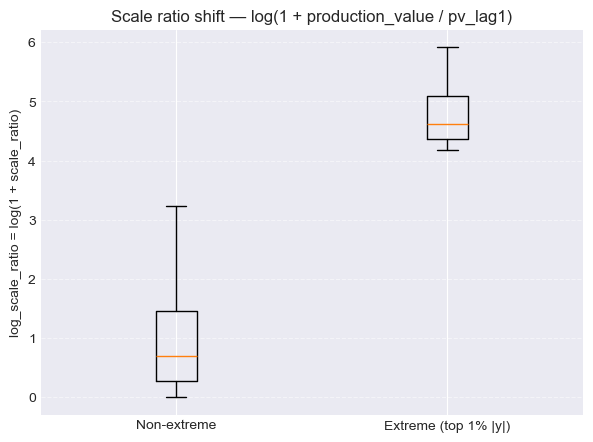

In [140]:


# due gruppi
g0 = tmp3.loc[~tmp3["is_extreme_abs_p99"], "log_scale_ratio"]
g1 = tmp3.loc[tmp3["is_extreme_abs_p99"], "log_scale_ratio"]

plt.figure(figsize=(7,5))
plt.boxplot([g0, g1], labels=["Non-extreme", "Extreme (top 1% |y|)"], showfliers=False)
plt.title("Scale ratio shift — log(1 + production_value / pv_lag1)")
plt.ylabel("log_scale_ratio = log(1 + scale_ratio)")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()


## Task 5 — Outlier mechanism diagnosis (ratio / scale-change check)

To understand why `revenue_change` shows extreme values, we test whether outliers are consistent with a **YoY base effect** driven by the prior-year denominator (`pv_lag1 = production_value_{t-1}`), rather than purely “random noise”.

**Setup**
- We work on supervised years **2019–2021** (n = 8,829) and compute `pv_lag1` via `groupby(company_id).shift(1)`.
- We define **extreme events** as the **top 1%** of \(|revenue_change|\): threshold \(\approx 6313.31\) (89 cases).

**Denominator effect (quantified)**
- `pv_lag1` p5 threshold: \(\approx 78.4M\)
- `pv_lag1` p10 threshold: \(\approx 126.1M\)
- Among extreme events:
  - **33.71%** occur with `pv_lag1` in the **bottom 5%**
  - **48.31%** occur with `pv_lag1` in the **bottom 10%**

**Scale-ratio mechanism (strong evidence)**
We compute the scale ratio \( \text{scale\_ratio} = \frac{production\_value}{pv\_lag1} \).
- Non-extreme cases: median ratio \(\approx 1.0\), p95 \(\approx 16.1\)
- Extreme cases: median ratio \(\approx 100.8\), p95 \(\approx 580.2\)
A boxplot of \( \log(1+\text{scale\_ratio}) \) shows a clear distributional shift: extreme \(|revenue_change|\) events correspond to **much larger scale ratios**.

**Interpretation**
- Extremes are **not** primarily a “division-by-zero” phenomenon (denominators do not approach zero), but they are frequently linked to **large changes in magnitude** between consecutive years (base effects / scale-change).
- Not all extremes are explained by small denominators, suggesting additional mechanisms (e.g., structural or extraordinary events) may also contribute.

**Modeling implication**
These findings justify robust handling of the target (signed-log already adopted) and motivate using `pv_lag1` (and optionally a small-denominator flag) as key predictors; a small subset of scale-change cases can dominate error and should be expected to drive tail-risk in evaluation.


## Task 6 ATECO segmentation (The "K-Shape" Check) Carla

**Output**
- Table: top 10 `ateco_sector` by count with:
  - count, median `revenue_change`, p95 `revenue_change`
- **Specific check**: Pivot table of median `revenue_change` by `ateco_sector` vs `fiscal_year`.

**Why**
- To confirm if the 2020 shock affected sectors asymmetrically (e.g., Tourism crashing vs IT stable), known as K-Shaped recovery.

In [141]:
sector_summary = (
    df.groupby("ateco_sector")
      .agg(
          count=(target, "size"),
          median_revenue_change=(target, "median"),
          p95_revenue_change=(target, lambda s: s.quantile(0.95)),
          p99_revenue_change=(target, lambda s: s.quantile(0.99))
      )
      .sort_values("count", ascending=False)
      .head(10)
)

sector_summary


,count,median_revenue_change,p95_revenue_change,p99_revenue_change
ateco_sector,,,,
46,1688,-6.87,1860.3130,6834.5348
47,1491,6.64,1575.0750,3526.1810
41,1465,8.41,2041.5165,7561.0950
43,1189,10.17,1467.3020,3314.3297
25,1095,4.93,1775.8380,5441.2826
10,958,-3.04,1635.1770,4977.5532
62,950,14.68,1870.4100,5370.1820
56,754,-2.72,1686.3490,9194.6268
45,662,1.32,1745.5250,8208.3590


In [142]:
# --- 1) ATECO macro mapping (range dict + override) ---
ATECO_RANGES = {
    (1, 3):  "Agriculture",
    (5, 9):  "Mining",
    (10, 33): "Manufacturing",
    (36, 39): "Water & Waste",
    (41, 43): "Construction",
    (45, 47): "Trade",
    (49, 53): "Transport",
    (55, 56): "Accommodation & Food",
    (58, 63): "Information & Communication",
    (64, 66): "Finance & Insurance",
    (69, 75): "Professional Services",
    (77, 82): "Administrative Services",
    (86, 88): "Health & Social Work",
    (90, 93): "Arts & Entertainment",
    (94, 96): "Other Services",
}
ATECO_SINGLE = {35: "Energy", 68: "Real Estate", 84: "Public Administration", 85: "Education"}

def map_ateco_category(code):
    code = int(code)
    if code in ATECO_SINGLE:
        return ATECO_SINGLE[code]
    for (lo, hi), label in ATECO_RANGES.items():
        if lo <= code <= hi:
            return label
    return "Other"

df["ateco_macro"] = df["ateco_sector"].astype(int).apply(map_ateco_category)

# --- 2) Data for Task 6 ---
years = [2019, 2020, 2021]
df_k = df.loc[df["fiscal_year"].isin(years), ["ateco_macro", "fiscal_year", "revenue_change"]].dropna()

# --- 3) Median pivot ---
sector_year_pivot = (
    df_k.pivot_table(
        index="ateco_macro",
        columns="fiscal_year",
        values="revenue_change",
        aggfunc="median"
    )
    .round(2)
)

# --- 4) n_total only (KIS) ---
n_total = (
    df_k.groupby("ateco_macro")["revenue_change"]
       .size()
       .rename("n_total")
       .astype(int)
)

# --- 5) K-shape table + add n_total ---
kshape = sector_year_pivot.copy()
kshape["drop_2020"]    = kshape[2020] - kshape[2019]
kshape["rebound_2021"] = kshape[2021] - kshape[2020]
kshape["net_21_vs_19"] = kshape[2021] - kshape[2019]

# join n_total (only)
kshape = kshape.join(n_total, how="left")

# (optional) put n_total first for readability
kshape = kshape[["n_total", 2019, 2020, 2021, "drop_2020", "rebound_2021", "net_21_vs_19"]]

# sort by biggest COVID drop
kshape = kshape.sort_values("drop_2020")

kshape


,n_total,2019,2020,2021,drop_2020,rebound_2021,net_21_vs_19
ateco_macro,,,,,,,
Real Estate,323,12.94,-25.67,36.02,-38.61,61.69,23.08
Information & Communication,711,33.20,7.34,2.70,-25.86,-4.64,-30.50
Accommodation & Food,564,-8.38,-32.53,34.89,-24.15,67.42,43.27
Manufacturing,1534,10.27,-10.24,6.04,-20.51,16.28,-4.23
Construction,1982,6.48,-8.73,29.56,-15.21,38.29,23.08
Professional Services,408,8.03,-3.14,1.09,-11.17,4.23,-6.94
Trade,2861,-9.85,16.84,-3.90,26.69,-20.74,5.95
Administrative Services,446,-4.04,23.46,-18.71,27.50,-42.17,-14.67


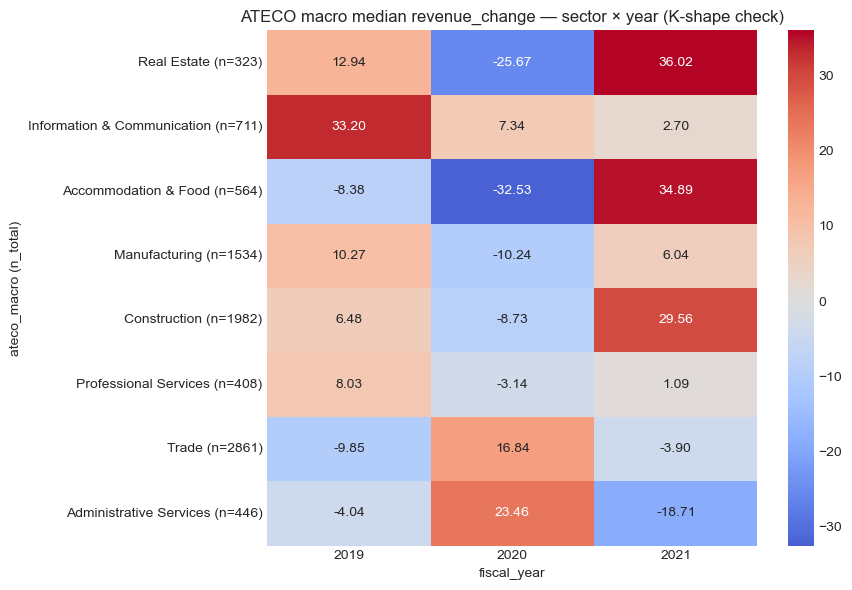

In [143]:

M = kshape[[2019, 2020, 2021]].copy()


order = kshape["drop_2020"].sort_values().index
M = M.loc[order]

labels = [
    f"{idx} (n={int(kshape.loc[idx, 'n_total'])})"
    for idx in M.index
]
M.index = labels

plt.figure(figsize=(9, 6))  # un po' più larga per farci stare le label
sns.heatmap(M, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("ATECO macro median revenue_change — sector × year (K-shape check)")
plt.xlabel("fiscal_year")
plt.ylabel("ateco_macro (n_total)")
plt.tight_layout()
plt.show()


## Task 6 — Sector heterogeneity (ATECO macro, median `revenue_change`)

We analyze the **median** `revenue_change` by **ATECO macro sector** across **2019–2021** (only rows with non-null target), to check whether the COVID shock/recovery pattern is **sector-dependent**. Sample sizes (`n_total`) are reported next to each sector label.

### Key takeaways
- **Strong cross-sector heterogeneity:** the direction and magnitude of the 2020 shock and the 2021 recovery differ substantially across sectors, even when the overall aggregate distribution looks relatively stable in IQR/p95.
- **Clear “V-shape” sectors (negative 2020, strong rebound 2021):**
  - **Accommodation & Food (n=564):** 2019 −8.38 → 2020 −32.53 → 2021 +34.89  
    (large rebound: +67.42; net +43.27 vs 2019)
  - **Real Estate (n=323):** 12.94 → −25.67 → +36.02  
    (rebound +61.69; net +23.08 vs 2019)
  - **Construction (n=1982):** 6.48 → −8.73 → +29.56  
    (rebound +38.29; net +23.08 vs 2019)
- **Partial recovery / normalization:**
  - **Manufacturing (n=1534):** 10.27 → −10.24 → 6.04  
    (rebound present, but still slightly below 2019: net −4.23)
  - **Professional Services (n=408):** 8.03 → −3.14 → 1.09  
    (small rebound, net −6.94 vs 2019)
- **Opposite pattern (2020 improvement, 2021 deterioration):**
  - **Trade (n=2861):** −9.85 → +16.84 → −3.90  
    (2020 boost, then partial reversal in 2021; net +5.95 vs 2019)
  - **Administrative Services (n=446):** −4.04 → +23.46 → −18.71  
    (strong reversal in 2021; net −14.67 vs 2019)
- **Information & Communication (n=711):** 33.20 → 7.34 → 2.70  
  (progressive normalization/downshift; net −30.50 vs 2019)

### Interpretation note
These are **medians**, so they describe the “typical” firm-year movement within each sector, not the extreme tail behavior. The heatmap highlights that a single “COVID effect” is not universal: sector-specific dynamics can be materially different in sign and shape.


## **7. Geographic Coverage**

Before examining aspects related to geographical location, we need to analyze the distribution of companies across different areas of Italy.
Our goal is to assess how accurately the data represents reality and what biases it may contain.
This will allow us to understand the results of our models, rather than finding direct links between geographical location and revenue growth.

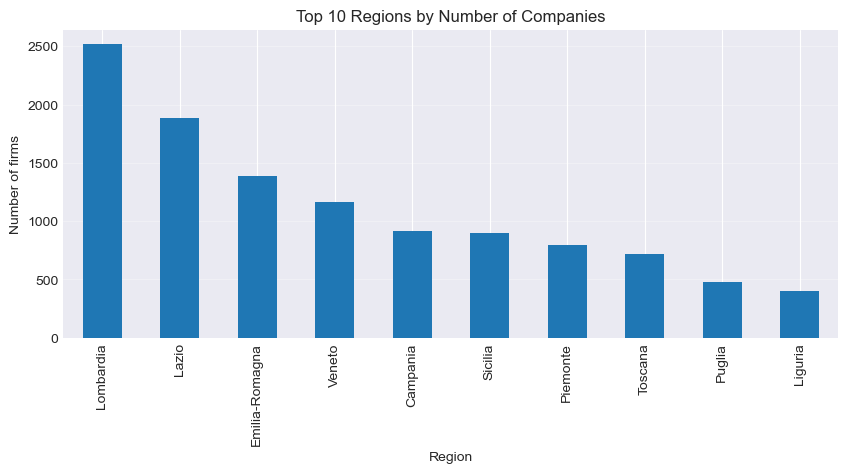

In [144]:
# Company count by region
region_counts = train_df['region'].value_counts().sort_values(ascending=False)
region_counts.head(10)

import matplotlib.pyplot as plt
region_counts.head(10).plot(kind='bar', figsize=(10,4))
plt.title("Top 10 Regions by Number of Companies")
plt.ylabel("Number of firms")
plt.xlabel("Region")
plt.grid(axis='y', alpha=0.3)
plt.show()

### **Interpretation**
The graph above shows that the distribution of companies across regions is uneven, with a high concentration in regions such as ***Lombardia and Lazio***.

This means that the data is not evenly distributed across different areas, so reagions with a higher number of companies or representatives may have a greater influence on the results.

The dataset includes more data from economically important regions, especially **Lombardia**. Regions like **Lazio**, **Emilia-Romagna**, and **Veneto** also have a lot of representation. In comparison, southern regions such as **Campania**, **Sicilia**, and **Puglia** have fewer observations, but they are still included.

## **8. Company Size Buckets**
One of the factors that most influences financial stability is the size of the company. To measure this aspect, we use total assets and group companies according to their size to see whether their revenue varies significantly depending on size.

In [145]:
#Use train-years only to define buckets
#We want to convert continuous variable into size categories(bucketing)
size_df = train_df.copy() #so we don't modify the train_df

size_df['size_bucket'] = pd.qcut(
    size_df['total_assets'],
    q=4,                                                      #splititng companies into 4 groups with the same number of obs.
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

size_summary = (
    size_df
    .groupby('size_bucket')['revenue_change']     #for each size bucket we will have all revenue changes
    .agg(                                         #summary stats for each size bucket
        count='count',                            #count will enable us to see how many obs in each bucket
        p25=lambda x: x.quantile(0.25),
        median='median',
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
        IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
)

size_summary

,count,p25,median,p75,p95,IQR
size_bucket,,,,,,
Small,2189,-89.96,-72.180,-23.4200,176.3220,66.5400
Medium,2185,-70.12,-22.970,91.0100,519.9560,161.1300
Large,2235,-37.63,67.980,317.4350,1360.0600,355.0650
Very Large,2220,16.17,265.865,998.3575,4875.9955,982.1875


We divide firm size into four groups based on total assets. This changes a complex number into clear categories (Small, Medium, Large, Very Large), making it easier to compare revenue changes across different firm sizes without being affected by very high or very low asset values.

### **Interpretation**
The table highlights how the central distribution of revenues changes based on company size.

For small and medium-sized enterprises, both the median and interquartile range (IQR) are below or close to zero, highlighting that most companies in these categories experience weak or negative revenue growth.



As companies grow, their revenue variations tend to be higher and more widespread.   Large companies have a positive median, but they can still experience significant losses. Very large companies show positive revenue variations even at the 25th percentile. The increase in IQR for all sizes means that as companies grow, their financial results become more variable, especially at the upper end of the distribution.

In [180]:

df = train_df.copy()


print(df[["production_value", "total_assets"]].quantile([0.1, 0.5, 0.9, 0.99]),'\n')



turnover = df["production_value"]
assets   = df["total_assets"]

# Single size proxy (EUR): "economic size"
size_eur = np.maximum(turnover, assets)

# Economically interpretable thresholds (EUR)
# (chosen to match your scale: p10 ~ 100M, p90 ~ few B, p99 ~ tens of B)
T1 = 100e6   # 100M
T2 = 1e9     # 1B
T3 = 10e9    # 10B

df["size_bucket_econ"] = pd.cut(
    size_eur,
    bins=[-np.inf, T1, T2, T3, np.inf],
    labels=["Small", "Medium", "Large", "Very Large"]
)

print(df["size_bucket_econ"].value_counts(dropna=False))


      production_value  total_assets
0.10      1.285573e+08  9.459032e+07
0.50      8.040019e+08  5.212379e+08
0.90      6.385392e+09  3.885697e+09
0.99      5.678041e+10  3.472548e+10 

size_bucket_econ
Medium        5739
Large         4625
Very Large     808
Small          656
Name: count, dtype: int64


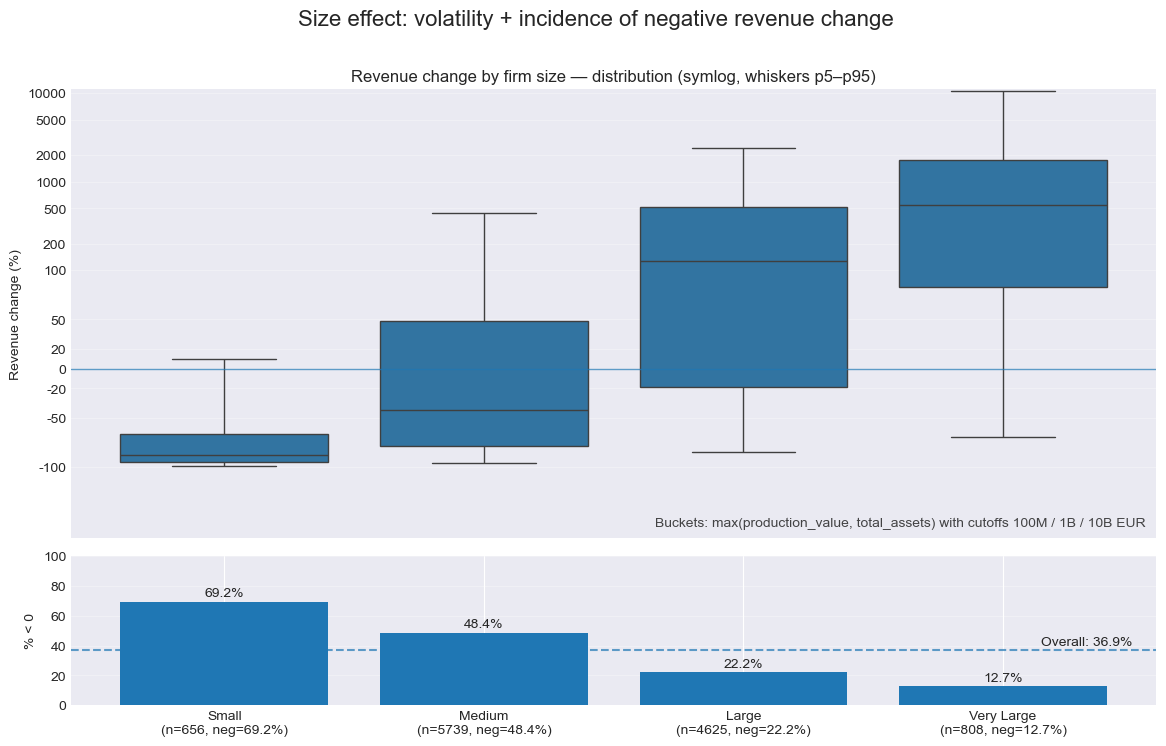

In [179]:

order = ["Small", "Medium", "Large", "Very Large"]

# Stats
stats = (
    df.assign(is_neg=df["revenue_change"] < 0)
      .groupby("size_bucket_econ")
      .agg(n=("revenue_change", "size"),
           neg_share=("is_neg", "mean"))
      .reindex(order)
)

overall_neg_pct = (df["revenue_change"] < 0).mean() * 100

# Plot
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06}
)


sns.boxplot(
    data=df,
    x="size_bucket_econ",
    y="revenue_change",
    order=order,
    showfliers=False,
    whis=(5, 95),
    ax=ax1
)

ax1.axhline(0, linewidth=1, alpha=0.7)
ax1.set_yscale("symlog", linthresh=100)


yticks = [-100, -50, -20, 0, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000]
ax1.set_yticks(yticks)
ax1.set_yticklabels([str(t) for t in yticks])

ax1.set_title("Revenue change by firm size — distribution (symlog, whiskers p5–p95)")
ax1.set_ylabel("Revenue change (%)")
ax1.set_xlabel("")
ax1.grid(axis="y", alpha=0.3)
ax1.tick_params(axis="x", labelbottom=False)


ax1.text(
    0.99, 0.02,
    "Buckets: max(production_value, total_assets) with cutoffs 100M / 1B / 10B EUR",
    transform=ax1.transAxes,
    ha="right", va="bottom",
    fontsize=10, alpha=0.85
)


neg_pct = (stats["neg_share"] * 100).values
x = np.arange(len(order))

ax2.bar(x, neg_pct)
ax2.axhline(overall_neg_pct, linestyle="--", alpha=0.7)
ax2.text(len(order) - 0.5, overall_neg_pct + 1, f"Overall: {overall_neg_pct:.1f}%",
         ha="right", va="bottom")

ax2.set_ylim(0, 100)
ax2.set_yticks([0, 20, 40, 60, 80, 100])
ax2.set_ylabel("% < 0")
ax2.grid(axis="y", alpha=0.3)

for i, v in enumerate(neg_pct):
    ax2.text(i, v + 1.5, f"{v:.1f}%", ha="center", va="bottom")

labels = [
    f"{c}\n(n={int(stats.loc[c,'n'])}, neg={stats.loc[c,'neg_share']*100:.1f}%)"
    for c in order
]
ax2.set_xticks(x)
ax2.set_xticklabels(labels)

plt.suptitle("Size effect: volatility + incidence of negative revenue change", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Interpretation — Small and Medium Firms

The first panel focuses on **Small** and **Medium** firms. Overall, revenue changes are **more often negative**, especially for smaller companies.

* **Small firms** show a **negative median** and a relatively tight interquartile range (IQR), meaning declines are common and outcomes are comparatively concentrated around modest negative values.
* **Medium firms** still have a **negative median**, but the distribution is **wider**: alongside many negative outcomes, a meaningful share of firms also shows positive growth. This suggests **higher variability** and more heterogeneous performance compared with Small firms.

### Interpretation — Large and Very Large Firms

Moving to larger size groups, the distribution shifts and becomes more dispersed.

* **Large firms** have a **positive median**, and the spread increases in both directions. Growth becomes more typical, but outcomes vary more than in the Small/Medium groups.
* **Very Large firms** display the **widest dispersion**, with a pronounced positive tail: some firms experience extremely large revenue increases, consistent with **rare but impactful events** (e.g., major restructuring, acquisitions, consolidation effects). Negative outcomes still occur, so larger size does not remove downside risk—it mainly changes the balance and scale of outcomes.

### Takeaway

Firm size appears to affect two main aspects:

1. **Volatility increases with size** (larger firms show a much wider range of revenue changes).
2. **The incidence of negative revenue change decreases with size** (declines are far more common among Small firms than among Very Large firms).

In short, size is linked more to the **likelihood and magnitude of large swings** than to “typical” year-to-year performance.


## Task 9 Company Age Analysis (Startup Volatility) Tommaso

**Feature**: `years_in_business`

**Output**
- Scatter plot: `years_in_business` vs `abs(revenue_change)` (or `revenue_change`)
- Table by Age Bucket (e.g., <5 years, 5-15 years, >15 years):
  - Median target, Standard Deviation of target

**Why**
- Hypothesis: Young companies (startups) have explosive growth/fail rates; mature companies are stable.

**Takeaway**
- “Younger companies show significantly higher volatility, suggesting `years_in_business` is a key segmentation feature for handling outliers.”

In [149]:
def year_buckets_summary(df, years = 'years_in_business'):
    tmp = df[[years,target]].dropna(subset=[years, target]).copy()

    # volatility
    tmp["y_abs"] = tmp[target].abs()

    buckets = {
        'startups(<5)' : tmp[tmp[years]<5]["y_abs"],
        'mid(5-15)' : tmp[(tmp[years]>=5) & (tmp[years] <= 15)]['y_abs'],
        'mature(>15)' : tmp[tmp[years]> 15]['y_abs'],
    }

    out = {}
    for bucket, v in buckets.items():
        out[bucket] = {
            'median' : v.median(),
            'std': v.std(),
            "p25": v.quantile(0.25),
            "p75": v.quantile(0.75),
            "IQR": v.quantile(0.75) - v.quantile(0.25),
            "p99": v.quantile(0.99),
            "n": v.shape[0],
        }
    
    return pd.DataFrame(out).T

summary = year_buckets_summary(train_df)

summary

,median,std,p25,p75,IQR,p99,n
startups(<5),85.24,758.389712,53.6025,274.8025,221.2000,3722.4183,442.0
mid(5-15),85.16,1546.545080,48.7850,223.5750,174.7900,6041.9002,1375.0
mature(>15),86.68,5106.907615,50.9675,240.5100,189.5425,6675.6293,7012.0


### Company Age & Volatility (`years_in_business`)

**What we measured.** We analyzed volatility using `|revenue_change|` and summarized it by age buckets: **<5**, **5–15**, **>15** years.

**Key finding.** The **typical volatility** is very similar across age buckets:
- Medians are ~**85** in all groups.
- The central spread (IQR) is comparable across buckets.

**Where differences emerge.** The **tails** differ substantially:
- The **p99** of `|revenue_change|` increases with age (**~3.7k → 6.0k → 6.7k**), indicating that **extreme events are more pronounced among older firms**.

**Interpretation (hypothesis, not causal).** One possible driver is **one-off structural events** (e.g., **M&A / consolidations / divestitures**) that may be more common among older firms with more assets and resources. However, the dataset does **not** include a direct M&A indicator, so this remains speculative.


In [150]:

def mna_asset_cojump_analysis(
    df: pd.DataFrame,
    id_col: str,
    time_col: str,
    target_col: str = "revenue_change",
    pv_col: str = "production_value",
    assets_col: str = "total_assets",
    min_year: int = 2019,
    extreme_q: float = 0.99,         # p99 on |y|
    growth_q: float = 0.95,          # p95 on asset_growth
    denom_q: float = 0.10,           # p10 threshold for "non-tiny" denominators
    eps_denom: float = 1.0,          # guardrail for near-zero denominators
):
    """
    Step A: define extreme events on |revenue_change| (p99).
    Step B: compute asset co-jump via asset_growth = assets / assets_prev - 1.
    Step C: diagnose denominator effect via assets_prev quantiles and re-evaluate on non-tiny subset.
    """

    
    # 0) Build lag frame (DO NOT drop target here)
    cols_needed = [id_col, time_col, target_col, pv_col, assets_col]
    lag = df[cols_needed].copy()
    lag = lag.sort_values([id_col, time_col])

    lag["pv_prev"] = lag.groupby(id_col)[pv_col].shift(1)
    lag["assets_prev"] = lag.groupby(id_col)[assets_col].shift(1)

    # 1) Define analysis universe (years >= min_year, target not null)
    universe = lag[lag[time_col] >= min_year].copy()
    universe = universe.dropna(subset=[target_col])
    universe["abs_y"] = universe[target_col].abs()

    y_abs_thr = np.quantile(universe["abs_y"].to_numpy(), extreme_q)

    cands = universe[universe["abs_y"] >= y_abs_thr].copy()

    
    # 2) Compute asset_growth with robust denominator gates (assets_prev must be finite and > eps_denom; same for current assets)
    def _clean_growth_frame(frame: pd.DataFrame) -> pd.DataFrame:
        tmp = frame.dropna(subset=["assets_prev", assets_col]).copy()
        tmp = tmp[np.isfinite(tmp["assets_prev"]) & np.isfinite(tmp[assets_col])].copy()
        tmp = tmp[(tmp["assets_prev"] > eps_denom) & (tmp[assets_col] > 0)].copy()
        tmp["asset_growth"] = (tmp[assets_col] / tmp["assets_prev"]) - 1
        # remove inf/nan growth
        tmp = tmp[np.isfinite(tmp["asset_growth"])].copy()
        return tmp

    # Growth population should be comparable to candidates: same year filter and target non-null (so we compare against the same “modeling universe”)
    growth_pop = _clean_growth_frame(universe)
    cands_g = _clean_growth_frame(cands)

    asset_growth_thr = np.quantile(growth_pop["asset_growth"].to_numpy(), growth_q)
    cands_g["asset_jump"] = cands_g["asset_growth"] >= asset_growth_thr

    # 3) Denominator diagnostics (assets_prev quantiles) on the same growth population
    assets_prev_p05 = np.quantile(growth_pop["assets_prev"].to_numpy(), 0.05)
    assets_prev_p10 = np.quantile(growth_pop["assets_prev"].to_numpy(), denom_q)
    assets_prev_p25 = np.quantile(growth_pop["assets_prev"].to_numpy(), 0.25)

    cands_g["assets_prev_tiny"] = cands_g["assets_prev"] <= assets_prev_p10

    # 4) Stable subset re-evaluation (assets_prev > p10) + stable threshold
    growth_pop_stable = growth_pop[growth_pop["assets_prev"] > assets_prev_p10].copy()
    cands_stable = cands_g[cands_g["assets_prev"] > assets_prev_p10].copy()

    # guard: if stable pop is too small, avoid noisy quantiles
    if len(growth_pop_stable) > 50 and len(cands_stable) > 0:
        asset_growth_thr_stable = np.quantile(growth_pop_stable["asset_growth"].to_numpy(), growth_q)
        cands_stable["asset_jump_stable"] = cands_stable["asset_growth"] >= asset_growth_thr_stable
    else:
        asset_growth_thr_stable = np.nan
        cands_stable["asset_jump_stable"] = np.nan

    # 5) Outputs
    print(f"abs_y p{int(extreme_q*100)} threshold: {y_abs_thr}")
    print(f"n_candidates (raw): {len(cands)}  share%: {len(cands)/len(universe)*100:.3f}")

    print(f"asset_growth p{int(growth_q*100)} (global): {asset_growth_thr}")
    print(f"asset_jump share (cands): {cands_g['asset_jump'].mean():.3f}")

    print(f"assets_prev p05/p{int(denom_q*100)}/p25: {assets_prev_p05}  {assets_prev_p10}  {assets_prev_p25}")
    print(f"share assets_prev <= p{int(denom_q*100)} in candidates: {cands_g['assets_prev_tiny'].mean():.3f}")

    print(f"n_non_tiny: {len(cands_stable)}  share: {len(cands_stable)/len(cands_g):.3f}")
    print(f"asset_growth p{int(growth_q*100)} (stable): {asset_growth_thr_stable}")
    if cands_stable["asset_jump_stable"].notna().all():
        print(f"asset_jump_stable share (non-tiny): {cands_stable['asset_jump_stable'].mean():.3f}")

    top_cols = [id_col, time_col, target_col, "abs_y", pv_col, "pv_prev",
                assets_col, "assets_prev", "asset_growth", "asset_jump", "assets_prev_tiny"]
    print("\nTop 10 candidates by abs_y (with assets co-jump):")
    print(cands_g.sort_values("abs_y", ascending=False)[top_cols].head(10))

    return {
        "lag": lag,
        "universe": universe,
        "candidates_raw": cands,
        "candidates_with_growth": cands_g,
        "candidates_non_tiny": cands_stable,
        "thresholds": {
            "y_abs_thr": y_abs_thr,
            "asset_growth_thr": asset_growth_thr,
            "assets_prev_p10": assets_prev_p10,
            "asset_growth_thr_stable": asset_growth_thr_stable,
        }
    }

res = mna_asset_cojump_analysis(
    train_df,
    id_col=id_col,
    time_col=time_col,
    target_col=target,
    pv_col="production_value",
    assets_col="total_assets",
    min_year=2019,
    extreme_q=0.99,
    growth_q=0.95,
    denom_q=0.10,
    eps_denom=1.0,
)


abs_y p99 threshold: 6313.31359999999
n_candidates (raw): 89  share%: 1.008
asset_growth p95 (global): 15.838127538759146
asset_jump share (cands): 1.000
assets_prev p05/p10/p25: 62374840.158  95175661.30800001  208419852.72
share assets_prev <= p10 in candidates: 0.506
n_non_tiny: 44  share: 0.494
asset_growth p95 (stable): 10.599246718030866
asset_jump_stable share (non-tiny): 1.000

Top 10 candidates by abs_y (with assets co-jump):
       company_id  fiscal_year  revenue_change      abs_y  production_value  \
9793   COMP_02485         2021       302126.48  302126.48      1.012812e+11   
380    COMP_00096         2020       213030.29  213030.29      1.034987e+10   
5876   COMP_01490         2021       136091.65  136091.65      1.232272e+10   
8571   COMP_02174         2019        74020.61   74020.61      1.752024e+10   
11557  COMP_02932         2019        61346.04   61346.04      1.893038e+10   
3543   COMP_00896         2021        52783.86   52783.86      7.208317e+10   
1765   C

### M&A-like Signals from Financial Statements (Explaining Extreme `revenue_change`)

**Goal.** We looked for *indirect* signals of extraordinary events (e.g., consolidation / M&A / perimeter changes) behind the most extreme values of `revenue_change`, using only accounting variables available in the dataset.

---

#### 1) Candidate “extreme events” selection (Top 1%)
We defined extreme observations as the **top 1%** of `|revenue_change|` (years **≥ 2019**, non-null target).

- **Threshold:** `p99(|revenue_change|)` = **6313.31**
- **Candidates:** **89** rows (**~1.01%** of the eligible sample)

This yields a compact list of the most abnormal YoY revenue changes to investigate further.

---

#### 2) Co-jump test: do extreme revenue events coincide with a jump in firm scale?
We computed an **asset growth proxy**:

\[
\text{asset\_growth}_t = \frac{\text{total\_assets}_t}{\text{total\_assets}_{t-1}} - 1
\]

and compared candidates against the global distribution of `asset_growth`.

- **Global threshold:** `p95(asset_growth)` = **15.84**
- **Result:** **100%** of extreme revenue candidates also fall above this threshold  
  → extreme `|revenue_change|` is consistently accompanied by an extreme jump in `total_assets`.

---

#### 3) Denominator effect: are co-jumps driven by “tiny” prior-year assets?
Since ratio-based growth can explode when the prior-year denominator is small, we inspected the distribution of `total_assets_{t-1}`.

- `assets_prev` percentiles (global):  
  - **p05:** 62.37M  
  - **p10:** 95.18M  
  - **p25:** 208.42M
- Among the 89 candidates, **50.6%** have `assets_prev ≤ p10`  
  → about half of the extremes may be amplified by a low prior-year asset base.

---

#### 4) Stable-subset re-test (removing “tiny denominator” cases)
We re-evaluated the co-jump **only on candidates with non-tiny denominators** (`assets_prev > p10`), and recalculated the benchmark threshold on the same stable population.

- **Non-tiny candidates:** **44** rows (**~49.4%** of candidates)
- **Stable threshold:** `p95(asset_growth | assets_prev > p10)` = **10.60**
- **Result:** **100%** of non-tiny candidates still exceed the stable threshold

**Interpretation:** Even after controlling for denominator effects, extreme `|revenue_change|` events remain strongly associated with extreme increases in firm assets, suggesting **structural scale changes** rather than purely percentage artifacts.

---

#### 5) Conclusion (non-causal)
- Extreme `|revenue_change|` events (top 1%) show a robust **co-jump** with `total_assets`, and this persists even when excluding low-denominator cases.
- This pattern is **consistent with extraordinary structural events** such as **consolidation/M&A, perimeter changes, or major accounting reclassifications**, but **cannot be confirmed** without a dedicated M&A indicator.



## 10) Feature drift on 5 key variables (X drift) Tommaso

**5 features**
- `production_value`, `total_assets`, `total_debt`, `operating_income`, `current_ratio`

**Output**
- Table by `fiscal_year` for each feature: median + p95 (or mean+std)
- Note any strong shifts in 2021 vs train years

**Why**
- Feature drift can explain performance drop in 2021.

**Takeaway**
- “Key financial drivers show (limited/material) drift across years, impacting 2021 generalization.”


In [151]:


drift_col = ['production_value','total_assets','total_debt','operating_income','current_ratio']


df_drift = train_df[[time_col] + drift_col].copy()
summary = df_drift.groupby(time_col)[drift_col].agg(['median', lambda s: s.quantile(0.95)])
summary.columns = [f"{c}_{s if s!='<lambda_0>' else 'p95'}" for c,s in summary.columns]


baseline_years = [2019, 2020]
baseline = summary.loc[baseline_years].mean()


delta_pct = (summary / baseline - 1) * 100
delta_pct = delta_pct.round(2)

delta_2021 = delta_pct.loc[[2021]]

display(delta_2021.style.background_gradient(axis=1))


,production_value_median,production_value_p95,total_assets_median,total_assets_p95,total_debt_median,total_debt_p95,operating_income_median,operating_income_p95,current_ratio_median,current_ratio_p95
fiscal_year,,,,,,,,,,
2021,8.380000,-7.390000,5.950000,1.480000,4.390000,1.700000,4.000000,-14.550000,-1.580000,-0.400000


In [152]:

rank = delta_2021.T.rename(columns={2021: "delta_%"}).copy()
rank["abs_delta_%"] = rank["delta_%"].abs()
rank = rank.sort_values("abs_delta_%", ascending=False)
rank["drift_flag"] = np.where(rank["abs_delta_%"] >= 10, "MATERIAL (>=10%)", "limited")

display(rank)


fiscal_year,delta_%,abs_delta_%,drift_flag
operating_income_p95,-14.55,14.55,MATERIAL (>=10%)
production_value_median,8.38,8.38,limited
production_value_p95,-7.39,7.39,limited
total_assets_median,5.95,5.95,limited
total_debt_median,4.39,4.39,limited
operating_income_median,4.00,4.00,limited
total_debt_p95,1.70,1.70,limited
current_ratio_median,-1.58,1.58,limited
total_assets_p95,1.48,1.48,limited
current_ratio_p95,-0.40,0.40,limited


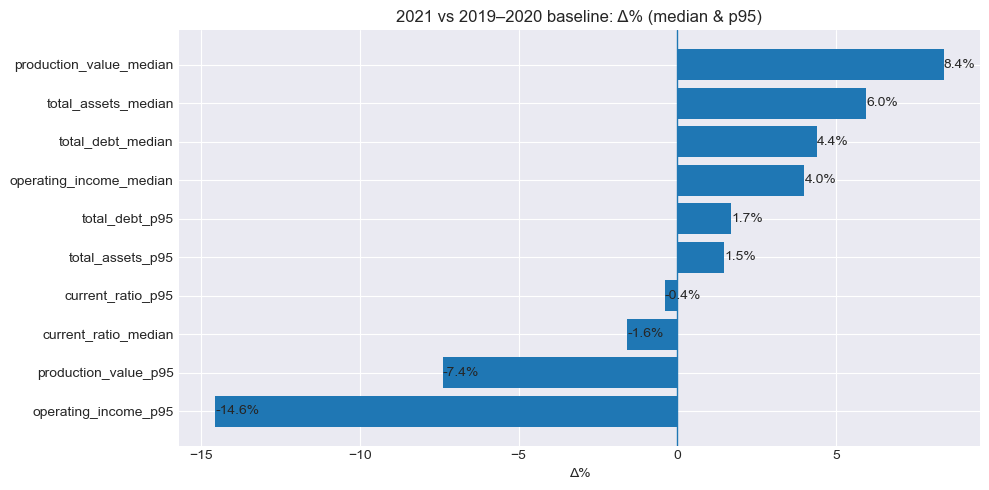

In [153]:


plot_df = rank.sort_values("delta_%") 

plt.figure(figsize=(10, 5))
plt.barh(plot_df.index, plot_df["delta_%"])
plt.axvline(0, linewidth=1)

for i, v in enumerate(plot_df["delta_%"].values):
    plt.text(v, i, f"{v:.1f}%", va="center")

plt.title("2021 vs 2019–2020 baseline: Δ% (median & p95)")
plt.xlabel("Δ%")
plt.tight_layout()
plt.show()


### Feature drift (X drift) — 2021 vs 2019–2020 baseline

We summarized 5 key features by `fiscal_year` using **median** and **p95**, then computed **Δ% for 2021 vs the 2019–2020 baseline**.

**Main findings (ranked by |Δ%|):**
- **operating_income_p95:** **-14.6%** (largest drift) → the upper tail of profitability is materially lower in 2021.
- **production_value_median:** **+8.4%** → typical firm scale increases in 2021.
- **production_value_p95:** **-7.4%** → the upper tail of revenue is lower in 2021.
- Other shifts are mild: `total_assets_median` (+6.0%), `total_debt_median` (+4.4%), `operating_income_median` (+4.0%); `current_ratio` is almost stable.

**Takeaway.**
Overall drift is **limited in medians**, but **more pronounced in the upper tail**, especially for `operating_income`. This tail-drift may contribute to weaker generalization on 2021 compared to training years (2019–2020).


In [154]:
# Target variable analysis
# TODO: Uncomment the relevant section for your challenge

# For Challenge 1: Bankruptcy Prediction
# print("\nBankruptcy Distribution:")
# print(train_df['bankruptcy_next_year'].value_counts())
# print(f"\nBankruptcy rate: {train_df['bankruptcy_next_year'].mean():.2%}")

# For Challenge 2: Financial Health Classification
# print("\nFinancial Health Distribution:")
# print(train_df['financial_health_class'].value_counts().sort_index())
# print("\nPercentages:")
# print(train_df['financial_health_class'].value_counts(normalize=True).sort_index())

# For Challenge 3: Revenue Forecasting
# print("\nRevenue Change Statistics:")
# print(train_df['revenue_change'].describe())
# print(f"\nMissing revenue_change: {train_df['revenue_change'].isnull().sum()}")

### Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

**Key Insights from EDA:**

TODO: Document your key findings
- 
- 
- 

## 3. Data Preprocessing

Handle missing values, outliers, and prepare data for modeling.

In [155]:
# Create a copy for preprocessing
df_processed = train_df.copy()

# TODO: Handle missing values
# - Decide on imputation strategy (median, mean, by group, etc.)
# - Document your rationale

# TODO: Handle outliers
# - Identify outliers (IQR, winsorization, etc.)
# - Decide on treatment strategy

# TODO: Encode categorical variables
# - One-hot encoding, label encoding, etc.

print("Preprocessing complete!")

Preprocessing complete!


In [156]:
# Train/Validation split
# IMPORTANT: Use temporal split, not random!

# For Challenges 1 & 2:
# train_years = [2018, 2019, 2020]
# val_year = 2021

# For Challenge 3 (time series):
# train_years = [2018, 2019]
# val_year = 2020
# test_year = 2021

# TODO: Implement temporal split
# df_train = df_processed[df_processed['fiscal_year'].isin(train_years)]
# df_val = df_processed[df_processed['fiscal_year'] == val_year]

print("Train/validation split complete!")

Train/validation split complete!


In [157]:
# Feature scaling
# IMPORTANT: Fit scaler on training data only!

from sklearn.preprocessing import StandardScaler, RobustScaler

# TODO: Choose and apply scaler
# scaler = StandardScaler()  # or RobustScaler() for outlier resistance
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

print("Feature scaling complete!")

Feature scaling complete!


## 4. Feature Engineering

Create new features based on domain knowledge.

In [158]:
# TODO: Engineer features
# Ideas:
# - Financial ratios (if not already present)
# - Year-over-year changes (growth rates)
# - Interaction features
# - Altman Z-Score or similar bankruptcy models
# - Sector-relative features (company vs sector average)
# - Temporal features (trends, volatility)

# Example: Year-over-year change
# df_processed = df_processed.sort_values(['company_id', 'fiscal_year'])
# df_processed['roe_yoy_change'] = df_processed.groupby('company_id')['roe'].diff()

print("Feature engineering complete!")
print(f"Total features: {df_processed.shape[1]}")

Feature engineering complete!
Total features: 30


**Engineered Features:**

TODO: List and explain your engineered features
1. 
2. 
3. 

## 5. Model Development

Train multiple models and compare performance.

In [159]:
#
#  Import models
#from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
#from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
#from sklearn.metrics import (
 #   classification_report, confusion_matrix, 
  #  f1_score, roc_auc_score, accuracy_score,
   # mean_squared_error, mean_absolute_error, r2_score
#)
#from xgboost import XGBClassifier, XGBRegressor

# For handling class imbalance (Challenges 1 & 2)
#from imblearn.over_sampling import SMOTE
#from sklearn.utils.class_weight import compute_class_weight

print("Model libraries imported!")

Model libraries imported!


In [160]:
# TODO: Prepare X and y
# feature_cols = [...]  # List your feature columns
# target_col = 'bankruptcy_next_year'  # or 'financial_health_class' or 'revenue_change'

# X_train = df_train[feature_cols]
# y_train = df_train[target_col]
# X_val = df_val[feature_cols]
# y_val = df_val[target_col]

print("Data prepared for modeling!")

Data prepared for modeling!


### Baseline Model

In [161]:
# TODO: Train baseline model
# For classification: Logistic Regression
# For regression: Linear Regression

# Example for Challenge 1 (Bankruptcy):
# baseline_model = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')
# baseline_model.fit(X_train_scaled, y_train)
# y_pred_baseline = baseline_model.predict(X_val_scaled)

# print("Baseline Model Performance:")
# print(classification_report(y_val, y_pred_baseline))
# print(f"F1-Score: {f1_score(y_val, y_pred_baseline):.4f}")

### Advanced Models

In [162]:
# TODO: Train multiple models
# - Random Forest
# - XGBoost
# - Gradient Boosting
# - etc.

# For classification with imbalance, consider:
# - SMOTE oversampling
# - Class weights
# - Threshold tuning

# Example for Random Forest with SMOTE:
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     random_state=RANDOM_STATE
# )
# rf_model.fit(X_train_resampled, y_train_resampled)

print("Advanced models trained!")

Advanced models trained!


In [163]:
# TODO: Hyperparameter tuning
# Use GridSearchCV or RandomizedSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Example:
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5, 10]
# }

# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=RANDOM_STATE),
#     param_grid,
#     cv=StratifiedKFold(n_splits=5),
#     scoring='f1',
#     n_jobs=-1
# )
# grid_search.fit(X_train_scaled, y_train)
# best_model = grid_search.best_estimator_

print("Hyperparameter tuning complete!")

Hyperparameter tuning complete!


## 6. Model Evaluation

Compare models and select the best one.

In [164]:
# TODO: Create model comparison table
# Compare all models on validation set using appropriate metrics

# For Challenge 1: F1-Score, AUC-ROC, Precision, Recall
# For Challenge 2: Weighted F1, Macro F1, Accuracy, Confusion Matrix
# For Challenge 3: RMSE, MAE, MAPE, R², Directional Accuracy

# Example comparison:
# models_comparison = pd.DataFrame({
#     'Model': ['Baseline', 'Random Forest', 'XGBoost'],
#     'F1-Score': [...],
#     'AUC-ROC': [...],
#     'Precision': [...],
#     'Recall': [...]
# })
# print(models_comparison)

In [165]:
# TODO: Confusion Matrix (for classification)
# from sklearn.metrics import ConfusionMatrixDisplay

# ConfusionMatrixDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('Confusion Matrix - Best Model')
# plt.show()

In [166]:
# TODO: ROC Curve (for binary classification)
# from sklearn.metrics import RocCurveDisplay

# RocCurveDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('ROC Curve - Best Model')
# plt.show()

**Model Selection:**

TODO: Justify your final model choice
- 
- 

## 7. Interpretation and Business Insights

Explain the model and extract business value.

In [167]:
# TODO: Feature Importance
# For tree-based models, use built-in feature importance
# For other models, consider SHAP values

# Example:
# feature_importance = pd.DataFrame({
#     'feature': feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
# plt.xlabel('Importance')
# plt.title('Top 15 Most Important Features')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

In [168]:
# TODO: Error Analysis
# - Which cases does the model misclassify/mispredicts?
# - Are there patterns in the errors?
# - How do errors vary by sector, size, region, etc.?

# Example:
# errors_df = df_val.copy()
# errors_df['prediction'] = y_pred
# errors_df['error'] = (errors_df['prediction'] != errors_df[target_col])

# print("Error rate by sector:")
# print(errors_df.groupby('ateco_sector')['error'].mean().sort_values(ascending=False))

**Business Insights:**

TODO: Translate technical findings into business language

**Key Risk Factors** (for bankruptcy/health challenges):
1. 
2. 
3. 

**Revenue Drivers** (for forecasting challenge):
1. 
2. 
3. 

**Actionable Recommendations:**
- 
- 
- 

## 8. Conclusions and Future Work

Summarize findings and discuss limitations.

**Summary:**

TODO: Summarize your work
- 
- 

**Performance vs Targets:**

TODO: Compare your results to challenge targets
- My F1-Score: [X.XX] vs Target: [0.55-0.70]
- ...

**Model Limitations:**

TODO: Discuss limitations honestly
1. 
2. 
3. 

**Future Improvements:**

TODO: What would you do with more time?
1. 
2. 
3. 

**Lessons Learned:**

TODO: Reflect on the experience
- 
- 

---

## Final Checklist

Before submitting, verify:

- [ ] All code cells execute without errors
- [ ] Markdown cells explain each step clearly
- [ ] Visualizations are clear and labeled
- [ ] Feature importance is analyzed
- [ ] Error analysis is performed
- [ ] Business insights are provided
- [ ] Model limitations are discussed
- [ ] Code is well-commented
- [ ] Results meet or exceed minimum performance targets
- [ ] No data leakage (temporal split, proper scaling, etc.)
- [ ] Citations for any external code/resources

**Good luck with your challenge!** 🚀

In [169]:
try:
    print("FINAL sees WORK KID:", KID)
except NameError:
    print("FINAL has its own kernel (good)")


FINAL has its own kernel (good)
